**Instalaciones**

In [5]:
!pip install roboflow kaggle -q

import os, zipfile, shutil, glob
from PIL import Image
from google.colab import files

print("Librerías cargadas sin problemas")

Librerías cargadas sin problemas


**Estructura de carpetas**

In [6]:
WORK_DIR = '/content/tfm'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']
TARGET_SIZE = (224, 224)

for cls in CLASSES:
    os.makedirs(f'{WORK_DIR}/dataset/{cls}', exist_ok=True)
os.makedirs(f'{WORK_DIR}/raw', exist_ok=True)

print("Estructura de directorios lista:")
for cls in CLASSES:
    print(f"  {WORK_DIR}/dataset/{cls}")

Estructura de directorios lista:
  /content/tfm/dataset/fluido
  /content/tfm/dataset/congestion
  /content/tfm/dataset/accidente
  /content/tfm/dataset/obras


**Subir y descomprimir Cityscapes**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Ruta al zip de Cityscapes en mi Drive
ZIP_PATH = '/content/drive/MyDrive/leftImg8bit_trainvaltest.zip'

print("Descomprimiendo Cityscapes desde Drive, puede tardar unos minutos...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(f'{WORK_DIR}/raw/cityscapes')

print("Listo, el zip se queda en Drive")

cityscapes_root = f'{WORK_DIR}/raw/cityscapes/leftImg8bit'
for split in ['train', 'val', 'test']:
    split_path = f'{cityscapes_root}/{split}'
    if os.path.exists(split_path):
        print(f"  {split}: {len(os.listdir(split_path))} ciudades")
    else:
        print(f"  {split}: no encontrado, revisar ruta")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descomprimiendo Cityscapes desde Drive, puede tardar unos minutos...
Listo, el zip se queda en Drive
  train: 18 ciudades
  val: 3 ciudades
  test: 6 ciudades


**Cityscapes → clase fluido**

In [8]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

counter = 0
MAX_FLUIDO_CITYSCAPES = 600

for split in ['train', 'val', 'test']:
    split_path = f'{cityscapes_root}/{split}'
    if not os.path.exists(split_path):
        continue
    for city in sorted(os.listdir(split_path)):
        city_path = f'{split_path}/{city}'
        if not os.path.isdir(city_path):
            continue
        for img_file in sorted(os.listdir(city_path)):
            if counter >= MAX_FLUIDO_CITYSCAPES:
                break
            if not img_file.endswith('.png'):
                continue
            src = f'{city_path}/{img_file}'
            if not is_valid_image(src):
                print(f"  Imagen corrupta, me la salto: {img_file}")
                continue
            dst = f'{WORK_DIR}/dataset/fluido/cityscapes_{counter:05d}.jpg'
            with Image.open(src) as img:
                img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
            counter += 1
        if counter >= MAX_FLUIDO_CITYSCAPES:
            break

print(f"Cityscapes procesado: {counter} imágenes para la clase fluido")

Cityscapes procesado: 600 imágenes para la clase fluido


**Kaggle: descargar Traffic Density Singapore**

In [9]:
import json

kaggle_creds = {
    "username": "Yushetf",
    "key": "KGAT_e52d98a98e4b09536184b85035faacbd"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json
print("Credenciales de Kaggle configuradas")

print("Descargando Traffic Density Singapore...")
!kaggle datasets download -d rahat52/traffic-density-singapore \
    -p {WORK_DIR}/raw/singapore --unzip

singapore_root = f'{WORK_DIR}/raw/singapore'
print("\nEstructura del dataset descargado:")
for root, dirs, fnames in os.walk(singapore_root):
    level = root.replace(singapore_root, '').count(os.sep)
    if level < 3:
        n_imgs = len([f for f in fnames if f.lower().endswith(('.jpg','.jpeg','.png'))])
        indent = '  ' * level
        label = f"  ({n_imgs} imgs)" if n_imgs > 0 else ""
        print(f"{indent}{os.path.basename(root)}/{label}")

Credenciales de Kaggle configuradas
Descargando Traffic Density Singapore...
Dataset URL: https://www.kaggle.com/datasets/rahat52/traffic-density-singapore
License(s): GNU Free Documentation License 1.3
100% 222M/222M [00:02<00:00, 114MB/s]


Estructura del dataset descargado:
singapore/
  Final Dataset/
    validation/
    training/
    testing/


**Singapore → fluido y congestion**

In [10]:
# Mapeo entre las carpetas de Singapore y las 4 clases
# Los nombres exactos salen del output de la celda anterior
SINGAPORE_MAP = {
    'empty':       'fluido',
    'low':         'fluido',
    'medium':      'fluido',
    'high':        'congestion',
    'traffic Jam': 'congestion',
}

counters_sg = {'fluido': 0, 'congestion': 0}

for root, dirs, fnames in os.walk(singapore_root):
    folder = os.path.basename(root).lower().strip()
    clase = SINGAPORE_MAP.get(folder)
    if clase is None:
        continue
    for fname in fnames:
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        src = os.path.join(root, fname)
        if not is_valid_image(src):
            continue
        n = counters_sg[clase]
        dst = f'{WORK_DIR}/dataset/{clase}/singapore_{n:05d}.jpg'
        with Image.open(src) as img:
            img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
        counters_sg[clase] += 1

print("Singapore procesado:")
for k, v in counters_sg.items():
    print(f"  {k}: {v} imágenes")

Singapore procesado:
  fluido: 3286 imágenes
  congestion: 480 imágenes


**Roboflow: descargar accidentes y obras**

In [11]:
from roboflow import Roboflow

API_KEY = "kdf00f3HMaycoX24Td4q"
rf = Roboflow(api_key=API_KEY)

# Descargo en formato yolov8, solo interesan las imágenes no las anotaciones
print("Descargando dataset de accidentes...")
project_crash = rf.workspace("smith-fsuvw").project("car-crash-vjfyg")
dataset_crash = project_crash.version(1).download(
    "yolov8", location=f'{WORK_DIR}/raw/roboflow_accidente')

print("\nDescargando dataset de obras...")
project_obras = rf.workspace("bus-hclqm").project("road-construction-ve7zd")
dataset_obras = project_obras.version(1).download(
    "yolov8", location=f'{WORK_DIR}/raw/roboflow_obras')

print("\nDescargas completadas")

Descargando dataset de accidentes...
loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to /content/tfm/raw/roboflow_accidente in yolov8:: 100%|██████████| 185/185 [00:00<00:00, 6717.63it/s]


Descargando dataset de obras...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/tfm/raw/roboflow_obras in yolov8:: 100%|██████████| 424/424 [00:00<00:00, 4867.43it/s]


Descargas completadas


**Explorar carpetas Roboflow antes de mapear**

In [12]:
for nombre, ruta in [('ACCIDENTE', f'{WORK_DIR}/raw/roboflow_accidente'),
                     ('OBRAS',     f'{WORK_DIR}/raw/roboflow_obras')]:
    print(f"\n── {nombre} ──")
    for root, dirs, fnames in os.walk(ruta):
        n = len([f for f in fnames if f.lower().endswith(('.jpg','.jpeg','.png'))])
        if n > 0:
            nivel = root.replace(ruta, '')
            print(f"  {nivel}  →  {n} imágenes")


── ACCIDENTE ──
  /valid/images  →  17 imágenes
  /test/images  →  13 imágenes
  /train/images  →  60 imágenes

── OBRAS ──
  /train/images  →  209 imágenes


**Roboflow → accidente y obras**

In [13]:
counters_rf = {'accidente': 0, 'obras': 0}

# Tuplas (ruta_raw, clase_destino)
FUENTES = [
    (f'{WORK_DIR}/raw/roboflow_accidente', 'accidente'),
    (f'{WORK_DIR}/raw/roboflow_obras',     'obras'),
]

for ruta_raw, clase in FUENTES:
    for root, dirs, fnames in os.walk(ruta_raw):
        # Solo proceso la carpeta images/, las labels no me hacen falta
        if not root.endswith('images'):
            continue
        for fname in fnames:
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            src = os.path.join(root, fname)
            if not is_valid_image(src):
                continue
            n = counters_rf[clase]
            dst = f'{WORK_DIR}/dataset/{clase}/roboflow_{n:05d}.jpg'
            with Image.open(src) as img:
                img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
            counters_rf[clase] += 1

print("Roboflow procesado:")
for k, v in counters_rf.items():
    print(f"  {k}: {v} imágenes")

Roboflow procesado:
  accidente: 90 imágenes
  obras: 209 imágenes


**Resumen final y diagnóstico**

In [14]:
print("=" * 40)
print("  ESTADO DEL DATASET - DIA 1")
print("=" * 40)

total = 0
minimo = float('inf')
clase_minima = ''

for cls in CLASSES:
    path = f'{WORK_DIR}/dataset/{cls}'
    n = len([f for f in os.listdir(path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total += n
    if n < minimo:
        minimo = n
        clase_minima = cls
    barra = '█' * (n // 30)
    print(f"  {cls:<12} {n:>5}  {barra}")

print("-" * 40)
print(f"  {'TOTAL':<12} {total:>5}")
print()

ratio = max(
    len(os.listdir(f'{WORK_DIR}/dataset/{c}')) for c in CLASSES
) / max(minimo, 1)

if ratio > 5:
    print(f"Desbalanceo importante (ratio {ratio:.1f}x)")
    print(f"  La clase '{clase_minima}' va a necesitar bastante augmentation")
elif ratio > 2:
    print(f"Desbalanceo moderado (ratio {ratio:.1f}x)")
    print(f"  Con augmentation estandar deberia ser suficiente")
else:
    print(f"Dataset bastante equilibrado (ratio {ratio:.1f}x)")

  ESTADO DEL DATASET - DIA 1
  fluido        3886  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  congestion     480  ████████████████
  accidente       90  ███
  obras          209  ██████
----------------------------------------
  TOTAL         4665

Desbalanceo importante (ratio 43.2x)
  La clase 'accidente' va a necesitar bastante augmentation


**Instalaciones y variables**

In [15]:
!pip install albumentations -q

import os, shutil, random, numpy as np
from PIL import Image
import albumentations as A
import cv2

WORK_DIR = '/content/tfm'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']
TARGET_SIZE = (224, 224)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Cuantas imágenes quiero por clase tras el equilibrado
TARGETS = {
    'fluido':     800,
    'congestion': 600,
    'accidente':  450,
    'obras':      450,
}

print("Todo cargado")

Todo cargado


**Recortar fluido a 800 imágenes**

In [16]:
fluido_path = f'{WORK_DIR}/dataset/fluido'
todas = [f for f in os.listdir(fluido_path)
         if f.lower().endswith(('.jpg','.jpeg','.png'))]

random.shuffle(todas)
mantener = set(todas[:800])

eliminadas = 0
for f in todas:
    if f not in mantener:
        os.remove(f'{fluido_path}/{f}')
        eliminadas += 1

print(f"fluido recortado: {eliminadas} imágenes eliminadas")
print(f"  Quedan: {len(os.listdir(fluido_path))} imágenes")

fluido recortado: 3086 imágenes eliminadas
  Quedan: 800 imágenes


**Pipeline de augmentation**


In [17]:
aug_agresivo = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(p=0.4),
    A.RandomFog(fog_coef_range=(0.1, 0.3), p=0.3),
    A.RandomRain(slant_range=(-10, 10), p=0.2),
    A.CLAHE(p=0.3),
    A.Resize(224, 224),
])

# Para congestion no hace falta ser tan agresivo
aug_moderado = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=0.4),
    A.Rotate(limit=10, p=0.4),
    A.GaussNoise(p=0.3),
    A.Resize(224, 224),
])


def augmentar_clase(clase, pipeline, objetivo):
    path = f'{WORK_DIR}/dataset/{clase}'
    originales = [f for f in os.listdir(path)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
    n_actual = len(originales)
    necesarias = objetivo - n_actual

    if necesarias <= 0:
        print(f"  {clase}: ya tiene {n_actual} imágenes, no toco nada")
        return

    generadas = 0
    idx = 0
    while generadas < necesarias:
        src = f'{path}/{originales[idx % len(originales)]}'
        img = cv2.imread(src)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = pipeline(image=img)['image']
        dst = f'{path}/aug_{generadas:05d}.jpg'
        cv2.imwrite(dst, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 90])
        generadas += 1
        idx += 1

    print(f"  {clase}: {n_actual} -> {n_actual + generadas} imágenes (+{generadas} sintéticas)")

print("Pipelines de augmentation listos")

Pipelines de augmentation listos


**Aplicar augmentation por clase**

In [18]:
print("Generando imágenes sintéticas...")
augmentar_clase('accidente',  aug_agresivo,  TARGETS['accidente'])
augmentar_clase('obras',      aug_moderado,  TARGETS['obras'])
augmentar_clase('congestion', aug_moderado,  TARGETS['congestion'])

print("\nAugmentation completado")
print("\nRecuento final:")
for cls in CLASSES:
    n = len([f for f in os.listdir(f'{WORK_DIR}/dataset/{cls}')
             if f.lower().endswith(('.jpg','.jpeg','.png'))])
    barra = '█' * (n // 30)
    print(f"  {cls:<12} {n:>5}  {barra}")

Generando imágenes sintéticas...
  accidente: 90 -> 450 imágenes (+360 sintéticas)
  obras: 209 -> 450 imágenes (+241 sintéticas)
  congestion: 480 -> 600 imágenes (+120 sintéticas)

Augmentation completado

Recuento final:
  fluido         800  ██████████████████████████
  congestion     600  ████████████████████
  accidente      450  ███████████████
  obras          450  ███████████████


**Split train/val/test (80/10/10)**

In [19]:
SPLIT_DIR = f'{WORK_DIR}/dataset_split'

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(f'{SPLIT_DIR}/{split}/{cls}', exist_ok=True)

counters_split = {s: {c: 0 for c in CLASSES} for s in ['train','val','test']}

for cls in CLASSES:
    imgs = [f for f in os.listdir(f'{WORK_DIR}/dataset/{cls}')
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)

    n = len(imgs)
    n_val  = max(1, int(n * 0.10))
    n_test = max(1, int(n * 0.10))
    n_train = n - n_val - n_test

    splits_map = (
        [('train', f) for f in imgs[:n_train]] +
        [('val',   f) for f in imgs[n_train:n_train+n_val]] +
        [('test',  f) for f in imgs[n_train+n_val:]]
    )

    for split, fname in splits_map:
        src = f'{WORK_DIR}/dataset/{cls}/{fname}'
        dst = f'{SPLIT_DIR}/{split}/{cls}/{fname}'
        shutil.copy2(src, dst)
        counters_split[split][cls] += 1

print("Split 80/10/10 completado:\n")
print(f"  {'':12} {'train':>6} {'val':>6} {'test':>6}")
print(f"  {'-'*32}")
for cls in CLASSES:
    t = counters_split['train'][cls]
    v = counters_split['val'][cls]
    te = counters_split['test'][cls]
    print(f"  {cls:<12} {t:>6} {v:>6} {te:>6}")

Split 80/10/10 completado:

                train    val   test
  --------------------------------
  fluido          640     80     80
  congestion      480     60     60
  accidente       360     45     45
  obras           360     45     45


**Verificación visual (muestra 1 imagen por clase)**

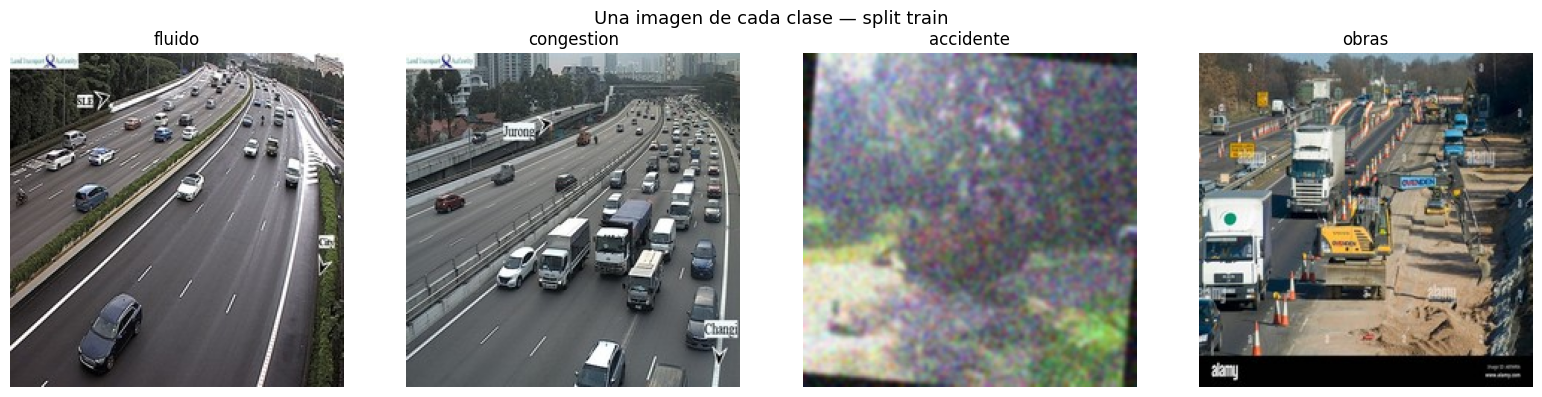

Comprobación visual ok


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Una imagen de cada clase — split train', fontsize=13)

for i, cls in enumerate(CLASSES):
    path = f'{SPLIT_DIR}/train/{cls}'
    sample = random.choice(os.listdir(path))
    img = Image.open(f'{path}/{sample}')
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("Comprobación visual ok")

**Guardar dataset_split en Drive**

In [21]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DEST = '/content/drive/MyDrive/TFM/dataset_split'

if os.path.exists(DRIVE_DEST):
    shutil.rmtree(DRIVE_DEST)

print("Guardando dataset_split en Drive, un momento...")
shutil.copytree(SPLIT_DIR, DRIVE_DEST)

print("Guardado correctamente")
print("\nVerificación:")
total = 0
for split in ['train', 'val', 'test']:
    n = sum(
        len(os.listdir(f'{DRIVE_DEST}/{split}/{cls}'))
        for cls in CLASSES
    )
    total += n
    print(f"  {split}: {n} imágenes")
print(f"  TOTAL: {total} imágenes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Guardando dataset_split en Drive, un momento...
Guardado correctamente

Verificación:
  train: 1840 imágenes
  val: 230 imágenes
  test: 230 imágenes
  TOTAL: 2300 imágenes


**Instalaciones y verificación de GPU**

In [22]:
!pip install torchvision -q

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os, time, copy
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Sin GPU detectada, activar en Entorno de ejecución > Cambiar tipo de entorno")

Dispositivo: cuda
GPU: Tesla T4
Memoria disponible: 15.6 GB


**Cargar dataset_split desde Drive**

In [23]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

WORK_DIR = '/content/tfm'
SPLIT_DIR = f'{WORK_DIR}/dataset_split'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']

# Copio a local para que el entrenamiento vaya más rápido
DRIVE_SOURCE = '/content/drive/MyDrive/TFM/dataset_split'

if not os.path.exists(SPLIT_DIR):
    print("Copiando dataset desde Drive...")
    shutil.copytree(DRIVE_SOURCE, SPLIT_DIR)
else:
    print("Dataset ya en local, no hace falta copiarlo otra vez")

print("\nImágenes por split:")
for split in ['train', 'val', 'test']:
    n = sum(len(os.listdir(f'{SPLIT_DIR}/{split}/{cls}')) for cls in CLASSES)
    print(f"  {split}: {n} imágenes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ya en local, no hace falta copiarlo otra vez

Imágenes por split:
  train: 1840 imágenes
  val: 230 imágenes
  test: 230 imágenes


**Transforms y DataLoaders**

In [24]:
SEED = 42
torch.manual_seed(SEED)

# Normalización estándar ImageNet, necesaria para transfer learning
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

image_datasets = {
    'train': datasets.ImageFolder(f'{SPLIT_DIR}/train', train_transforms),
    'val':   datasets.ImageFolder(f'{SPLIT_DIR}/val',   val_test_transforms),
    'test':  datasets.ImageFolder(f'{SPLIT_DIR}/test',  val_test_transforms),
}

dataloaders = {
    split: DataLoader(image_datasets[split],
                      batch_size=32,
                      shuffle=(split == 'train'),
                      num_workers=2)
    for split in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
print(f"Clases: {class_names}")
print(f"Índices: {image_datasets['train'].class_to_idx}")
print(f"\nBatches por split:")
for split in ['train', 'val', 'test']:
    print(f"  {split}: {len(dataloaders[split])} batches de 32")

Clases: ['accidente', 'congestion', 'fluido', 'obras']
Índices: {'accidente': 0, 'congestion': 1, 'fluido': 2, 'obras': 3}

Batches por split:
  train: 58 batches de 32
  val: 8 batches de 32
  test: 8 batches de 32


**Función de entrenamiento**

In [25]:
def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'val_loss': [],
                'train_acc': [],  'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' - ')

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc  = running_corrects.double() / len(image_datasets[phase])

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} loss={epoch_loss:.4f} acc={epoch_acc:.4f}', end='  ')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    elapsed = time.time() - since
    print(f'\n{model_name} entrenado en {elapsed//60:.0f}m {elapsed%60:.0f}s')
    print(f'  Mejor val accuracy: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

print("Función de entrenamiento lista")

Función de entrenamiento lista


**Entrenar ResNet50**

In [26]:
# ResNet50 con pesos de ImageNet
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Congelo todo excepto la capa final
for param in resnet.parameters():
    param.requires_grad = False

# Sustituyo el clasificador por uno de 4 clases
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 4)
resnet = resnet.to(device)

# Solo entreno la capa final en esta primera fase
optimizer_res = optim.Adam(resnet.fc.parameters(), lr=1e-3)
scheduler_res = optim.lr_scheduler.StepLR(optimizer_res, step_size=7, gamma=0.1)
criterion = nn.CrossEntropyLoss()

print("Entrenando ResNet50...")
resnet, history_res = train_model(
    resnet, 'ResNet50', criterion,
    optimizer_res, scheduler_res, num_epochs=15
)

torch.save(resnet.state_dict(), '/content/drive/MyDrive/TFM/resnet50_tfm.pth')
print("ResNet50 guardado en Drive")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 72.1MB/s]


Entrenando ResNet50...
Epoch 1/15 - train loss=0.8879 acc=0.6690  val loss=0.5177 acc=0.8348  
Epoch 2/15 - train loss=0.4720 acc=0.8391  val loss=0.3288 acc=0.9130  
Epoch 3/15 - train loss=0.4082 acc=0.8554  val loss=0.3041 acc=0.8870  
Epoch 4/15 - train loss=0.3614 acc=0.8663  val loss=0.2542 acc=0.9174  
Epoch 5/15 - train loss=0.3328 acc=0.8859  val loss=0.2451 acc=0.9130  
Epoch 6/15 - train loss=0.3102 acc=0.8837  val loss=0.2539 acc=0.8957  
Epoch 7/15 - train loss=0.2904 acc=0.8973  val loss=0.2317 acc=0.9261  
Epoch 8/15 - train loss=0.2558 acc=0.9098  val loss=0.2260 acc=0.9304  
Epoch 9/15 - train loss=0.2444 acc=0.9223  val loss=0.2206 acc=0.9130  
Epoch 10/15 - train loss=0.2478 acc=0.9163  val loss=0.2323 acc=0.9217  
Epoch 11/15 - train loss=0.2551 acc=0.9087  val loss=0.2250 acc=0.9217  
Epoch 12/15 - train loss=0.2466 acc=0.9190  val loss=0.2235 acc=0.9217  
Epoch 13/15 - train loss=0.2551 acc=0.9120  val loss=0.2157 acc=0.9304  
Epoch 14/15 - train loss=0.2462 acc=0

**Entrenar EfficientNetB0**

In [27]:
# EfficientNetB0 con pesos de ImageNet
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Congelo todas las capas
for param in efficientnet.parameters():
    param.requires_grad = False

# Cambio el clasificador final para mis 4 clases
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_features, 4)
efficientnet = efficientnet.to(device)

optimizer_eff = optim.Adam(efficientnet.classifier.parameters(), lr=1e-3)
scheduler_eff = optim.lr_scheduler.StepLR(optimizer_eff, step_size=7, gamma=0.1)

print("Entrenando EfficientNetB0...")
efficientnet, history_eff = train_model(
    efficientnet, 'EfficientNetB0', criterion,
    optimizer_eff, scheduler_eff, num_epochs=15
)

torch.save(efficientnet.state_dict(), '/content/drive/MyDrive/TFM/efficientnet_b0_tfm.pth')
print("EfficientNetB0 guardado en Drive")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 102MB/s]


Entrenando EfficientNetB0...
Epoch 1/15 - train loss=0.8560 acc=0.6924  val loss=0.5069 acc=0.8913  
Epoch 2/15 - train loss=0.5241 acc=0.8255  val loss=0.3718 acc=0.9043  
Epoch 3/15 - train loss=0.4351 acc=0.8582  val loss=0.3313 acc=0.9000  
Epoch 4/15 - train loss=0.4000 acc=0.8576  val loss=0.3137 acc=0.8913  
Epoch 5/15 - train loss=0.3391 acc=0.8826  val loss=0.2784 acc=0.9087  
Epoch 6/15 - train loss=0.3231 acc=0.8875  val loss=0.2542 acc=0.9000  
Epoch 7/15 - train loss=0.3085 acc=0.8880  val loss=0.2630 acc=0.9304  
Epoch 8/15 - train loss=0.3029 acc=0.8908  val loss=0.2538 acc=0.9087  
Epoch 9/15 - train loss=0.2860 acc=0.9114  val loss=0.2647 acc=0.9174  
Epoch 10/15 - train loss=0.2957 acc=0.8946  val loss=0.2391 acc=0.9174  
Epoch 11/15 - train loss=0.2781 acc=0.9043  val loss=0.2461 acc=0.9087  
Epoch 12/15 - train loss=0.2969 acc=0.8957  val loss=0.2384 acc=0.9174  
Epoch 13/15 - train loss=0.2880 acc=0.8995  val loss=0.2479 acc=0.9217  
Epoch 14/15 - train loss=0.2907

**Curvas de aprendizaje**

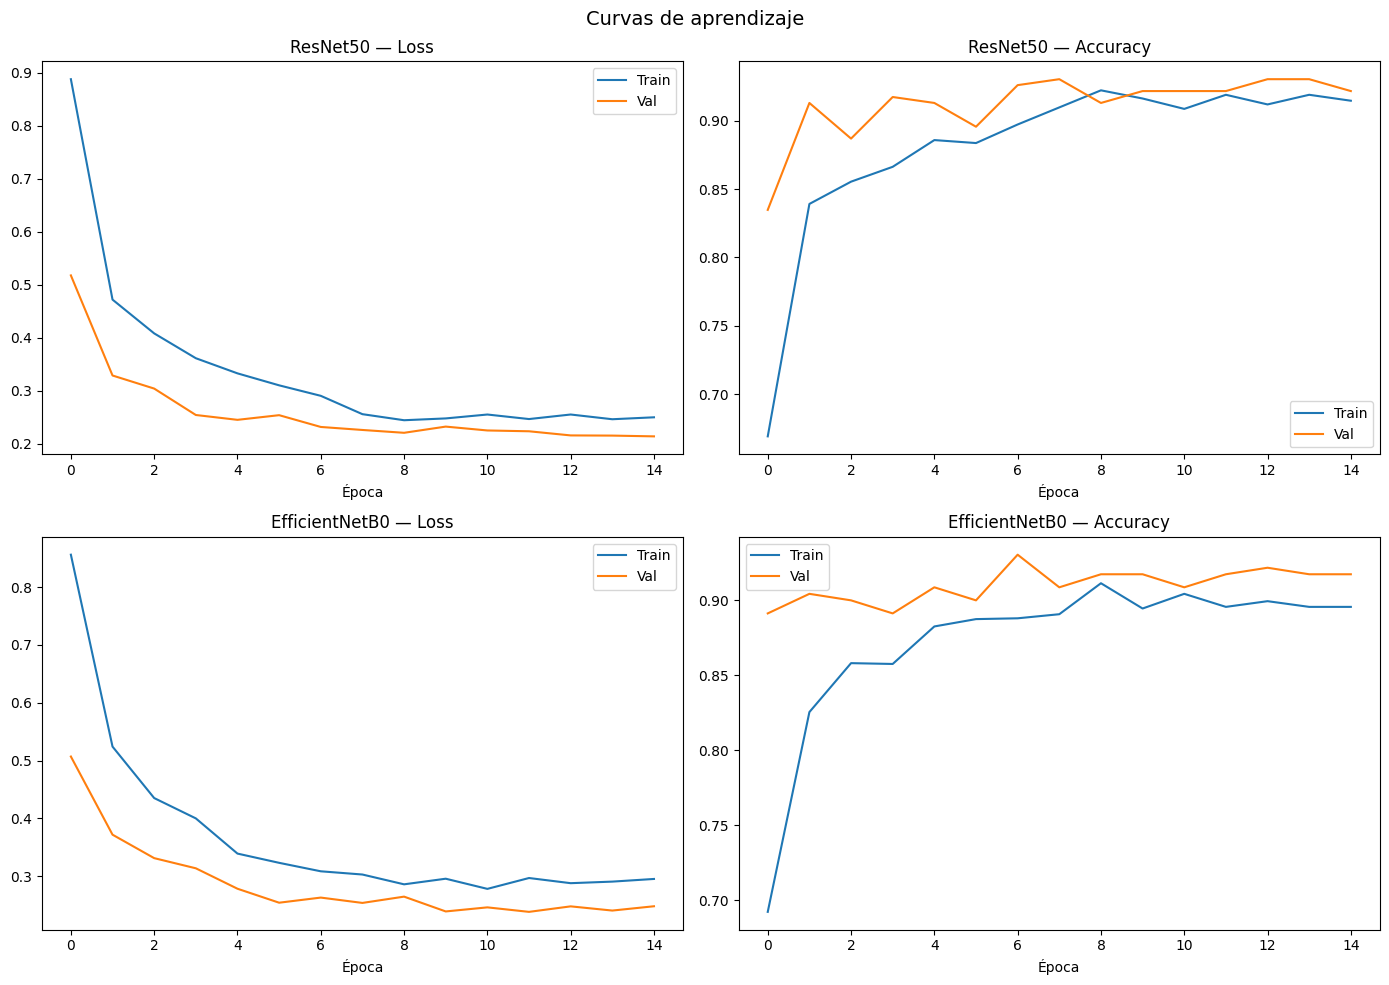

Curvas guardadas en Drive


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Curvas de aprendizaje', fontsize=14)

for i, (history, name) in enumerate([(history_res, 'ResNet50'),
                                       (history_eff, 'EfficientNetB0')]):
    axes[i][0].plot(history['train_loss'], label='Train')
    axes[i][0].plot(history['val_loss'],   label='Val')
    axes[i][0].set_title(f'{name} — Loss')
    axes[i][0].set_xlabel('Época')
    axes[i][0].legend()

    axes[i][1].plot(history['train_acc'], label='Train')
    axes[i][1].plot(history['val_acc'],   label='Val')
    axes[i][1].set_title(f'{name} — Accuracy')
    axes[i][1].set_xlabel('Época')
    axes[i][1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/curvas_aprendizaje.png', dpi=150)
plt.show()
print("Curvas guardadas en Drive")

**Evaluación en test y matrices de confusión**


  ResNet50 — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.92      1.00      0.96        45
  congestion       0.86      0.93      0.90        60
      fluido       0.95      0.88      0.91        80
       obras       0.98      0.91      0.94        45

    accuracy                           0.92       230
   macro avg       0.93      0.93      0.93       230
weighted avg       0.92      0.92      0.92       230



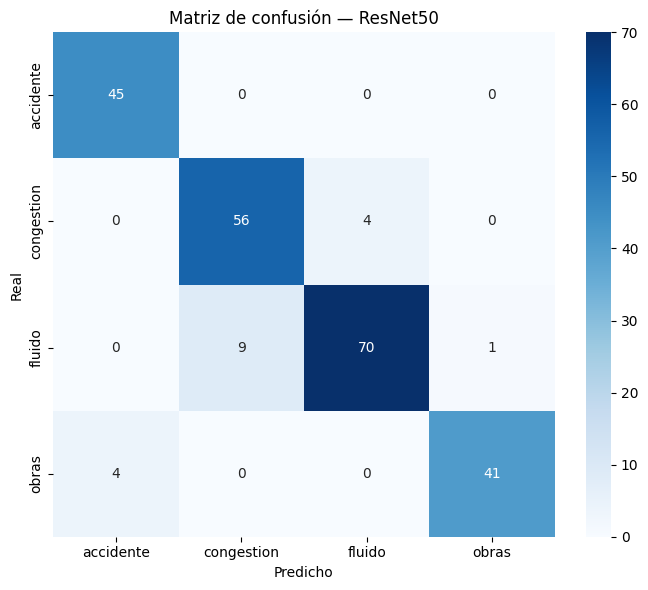


  EfficientNetB0 — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.87      1.00      0.93        45
  congestion       0.85      0.97      0.91        60
      fluido       0.99      0.89      0.93        80
       obras       1.00      0.84      0.92        45

    accuracy                           0.92       230
   macro avg       0.93      0.92      0.92       230
weighted avg       0.93      0.92      0.92       230



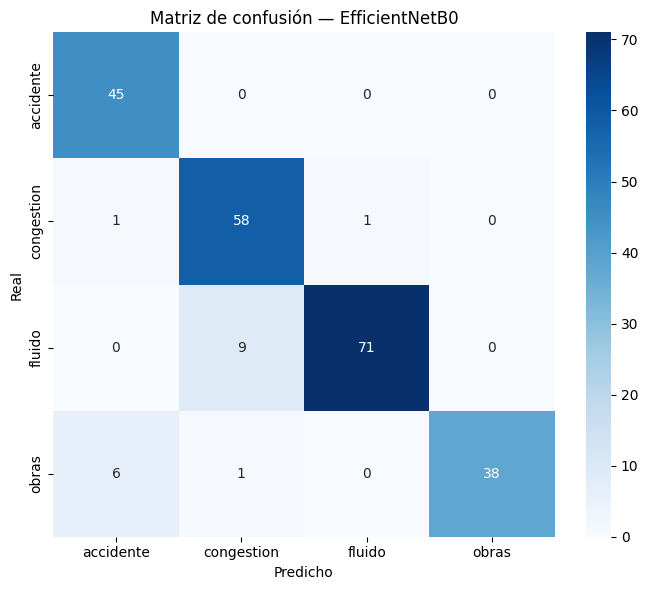

In [29]:
def evaluar_modelo(model, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"\n{'='*45}")
    print(f"  {model_name} — Resultados en TEST")
    print(f"{'='*45}")
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de confusión — {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/TFM/confusion_{model_name}.png', dpi=150)
    plt.show()

evaluar_modelo(resnet, 'ResNet50')
evaluar_modelo(efficientnet, 'EfficientNetB0')

**Baseline: CNN desde cero**

In [30]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            # Bloque 1: 224x224 -> 112x112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloque 2: 112x112 -> 56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloque 3: 56x56 -> 28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloque 4: 28x28 -> 14x14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline = BaselineCNN(num_classes=4).to(device)

total_params = sum(p.numel() for p in baseline.parameters())
print(f"Parámetros de la baseline CNN: {total_params:,}")

optimizer_base = optim.Adam(baseline.parameters(), lr=1e-3)
scheduler_base = optim.lr_scheduler.StepLR(optimizer_base, step_size=7, gamma=0.1)

print("\nEntrenando Baseline CNN...")
baseline, history_base = train_model(
    baseline, 'BaselineCNN', criterion,
    optimizer_base, scheduler_base, num_epochs=15
)

torch.save(baseline.state_dict(), '/content/drive/MyDrive/TFM/baseline_cnn.pth')
print("Baseline guardado en Drive")

Parámetros de la baseline CNN: 2,489,092

Entrenando Baseline CNN...
Epoch 1/15 - train loss=1.3988 acc=0.4913  val loss=0.8119 acc=0.6652  
Epoch 2/15 - train loss=0.7693 acc=0.6897  val loss=0.7761 acc=0.7000  
Epoch 3/15 - train loss=0.6484 acc=0.7370  val loss=0.5912 acc=0.7391  
Epoch 4/15 - train loss=0.5605 acc=0.7832  val loss=0.4923 acc=0.8087  
Epoch 5/15 - train loss=0.5711 acc=0.7766  val loss=0.4342 acc=0.8087  
Epoch 6/15 - train loss=0.5002 acc=0.7962  val loss=0.4720 acc=0.8174  
Epoch 7/15 - train loss=0.4555 acc=0.8190  val loss=0.3605 acc=0.8435  
Epoch 8/15 - train loss=0.3989 acc=0.8478  val loss=0.3173 acc=0.8696  
Epoch 9/15 - train loss=0.3561 acc=0.8674  val loss=0.3049 acc=0.8739  
Epoch 10/15 - train loss=0.3219 acc=0.8799  val loss=0.2949 acc=0.8783  
Epoch 11/15 - train loss=0.3001 acc=0.8848  val loss=0.2709 acc=0.9000  
Epoch 12/15 - train loss=0.2969 acc=0.8946  val loss=0.2660 acc=0.8957  
Epoch 13/15 - train loss=0.2807 acc=0.8891  val loss=0.2625 acc=

**Fine-tuning ResNet50**

In [31]:
# Cargo ResNet50 con los pesos del entrenamiento anterior
resnet_ft = models.resnet50(weights=None)
resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, 4)
resnet_ft.load_state_dict(torch.load('/content/drive/MyDrive/TFM/resnet50_tfm.pth'))
resnet_ft = resnet_ft.to(device)

# Descongelo solo layer3, layer4 y fc para el fine-tuning
for name, param in resnet_ft.named_parameters():
    if any(layer in name for layer in ['layer3', 'layer4', 'fc']):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in resnet_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_ft.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Learning rates diferenciados: más bajo para las capas que ya tienen conocimiento
optimizer_ft = optim.Adam([
    {'params': resnet_ft.layer3.parameters(), 'lr': 1e-5},
    {'params': resnet_ft.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_ft.fc.parameters(),     'lr': 1e-3},
])
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

print("\nEntrenando ResNet50 con fine-tuning...")
resnet_ft, history_ft = train_model(
    resnet_ft, 'ResNet50_FineTuning', criterion,
    optimizer_ft, scheduler_ft, num_epochs=15
)

torch.save(resnet_ft.state_dict(), '/content/drive/MyDrive/TFM/resnet50_finetuned.pth')
print("ResNet50 fine-tuned guardado en Drive")

Parámetros entrenables: 22,071,300 / 23,516,228 (93.9%)

Entrenando ResNet50 con fine-tuning...
Epoch 1/15 - train loss=0.2585 acc=0.9043  val loss=0.1752 acc=0.9522  
Epoch 2/15 - train loss=0.1118 acc=0.9652  val loss=0.1095 acc=0.9652  
Epoch 3/15 - train loss=0.0795 acc=0.9728  val loss=0.1081 acc=0.9696  
Epoch 4/15 - train loss=0.0626 acc=0.9783  val loss=0.1059 acc=0.9696  
Epoch 5/15 - train loss=0.0406 acc=0.9875  val loss=0.1229 acc=0.9696  
Epoch 6/15 - train loss=0.0189 acc=0.9946  val loss=0.0926 acc=0.9652  
Epoch 7/15 - train loss=0.0120 acc=0.9967  val loss=0.0911 acc=0.9652  
Epoch 8/15 - train loss=0.0108 acc=0.9962  val loss=0.0941 acc=0.9696  
Epoch 9/15 - train loss=0.0069 acc=0.9984  val loss=0.0828 acc=0.9739  
Epoch 10/15 - train loss=0.0057 acc=1.0000  val loss=0.0893 acc=0.9696  
Epoch 11/15 - train loss=0.0074 acc=0.9973  val loss=0.0918 acc=0.9696  
Epoch 12/15 - train loss=0.0065 acc=0.9989  val loss=0.0892 acc=0.9696  
Epoch 13/15 - train loss=0.0055 acc=0

**Fine-tuning EfficientNetB0**

In [32]:
efficientnet_ft = models.efficientnet_b0(weights=None)
efficientnet_ft.classifier[1] = nn.Linear(efficientnet_ft.classifier[1].in_features, 4)
efficientnet_ft.load_state_dict(torch.load('/content/drive/MyDrive/TFM/efficientnet_b0_tfm.pth'))
efficientnet_ft = efficientnet_ft.to(device)

# Descongelo los últimos bloques y el clasificador
for name, param in efficientnet_ft.named_parameters():
    if any(block in name for block in ['features.6', 'features.7', 'features.8', 'classifier']):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in efficientnet_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in efficientnet_ft.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Learning rates escalonados por profundidad
optimizer_eff_ft = optim.Adam([
    {'params': efficientnet_ft.features[6].parameters(), 'lr': 1e-5},
    {'params': efficientnet_ft.features[7].parameters(), 'lr': 1e-5},
    {'params': efficientnet_ft.features[8].parameters(), 'lr': 1e-4},
    {'params': efficientnet_ft.classifier.parameters(),  'lr': 1e-3},
])
scheduler_eff_ft = optim.lr_scheduler.StepLR(optimizer_eff_ft, step_size=5, gamma=0.1)

print("\nEntrenando EfficientNetB0 con fine-tuning...")
efficientnet_ft, history_eff_ft = train_model(
    efficientnet_ft, 'EfficientNetB0_FineTuning', criterion,
    optimizer_eff_ft, scheduler_eff_ft, num_epochs=15
)

torch.save(efficientnet_ft.state_dict(), '/content/drive/MyDrive/TFM/efficientnet_b0_finetuned.pth')
print("EfficientNetB0 fine-tuned guardado en Drive")

Parámetros entrenables: 3,160,864 / 4,012,672 (78.8%)

Entrenando EfficientNetB0 con fine-tuning...
Epoch 1/15 - train loss=0.2943 acc=0.8897  val loss=0.2044 acc=0.9304  
Epoch 2/15 - train loss=0.2461 acc=0.9136  val loss=0.1884 acc=0.9391  
Epoch 3/15 - train loss=0.2078 acc=0.9272  val loss=0.1836 acc=0.9391  
Epoch 4/15 - train loss=0.1871 acc=0.9283  val loss=0.1572 acc=0.9435  
Epoch 5/15 - train loss=0.1590 acc=0.9413  val loss=0.1759 acc=0.9391  
Epoch 6/15 - train loss=0.1415 acc=0.9505  val loss=0.1549 acc=0.9435  
Epoch 7/15 - train loss=0.1473 acc=0.9473  val loss=0.1465 acc=0.9522  
Epoch 8/15 - train loss=0.1320 acc=0.9527  val loss=0.1430 acc=0.9478  
Epoch 9/15 - train loss=0.1431 acc=0.9467  val loss=0.1360 acc=0.9522  
Epoch 10/15 - train loss=0.1293 acc=0.9522  val loss=0.1400 acc=0.9478  
Epoch 11/15 - train loss=0.1304 acc=0.9500  val loss=0.1489 acc=0.9478  
Epoch 12/15 - train loss=0.1356 acc=0.9511  val loss=0.1436 acc=0.9478  
Epoch 13/15 - train loss=0.1259 a

**Evaluación baseline y fine-tuning**


  BaselineCNN — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.93      0.93      0.93        45
  congestion       0.89      0.97      0.93        60
      fluido       0.97      0.90      0.94        80
       obras       0.91      0.93      0.92        45

    accuracy                           0.93       230
   macro avg       0.93      0.93      0.93       230
weighted avg       0.93      0.93      0.93       230



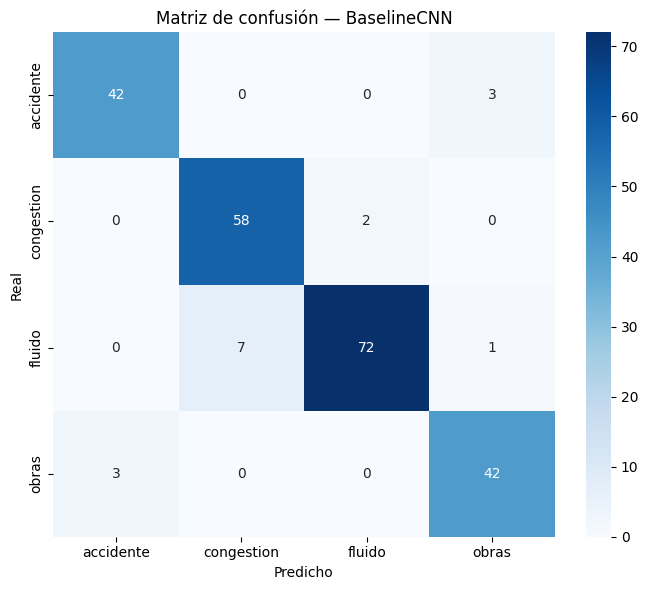


  ResNet50_FineTuning — Resultados en TEST
              precision    recall  f1-score   support

   accidente       1.00      1.00      1.00        45
  congestion       0.89      0.93      0.91        60
      fluido       0.95      0.93      0.94        80
       obras       1.00      0.98      0.99        45

    accuracy                           0.95       230
   macro avg       0.96      0.96      0.96       230
weighted avg       0.95      0.95      0.95       230



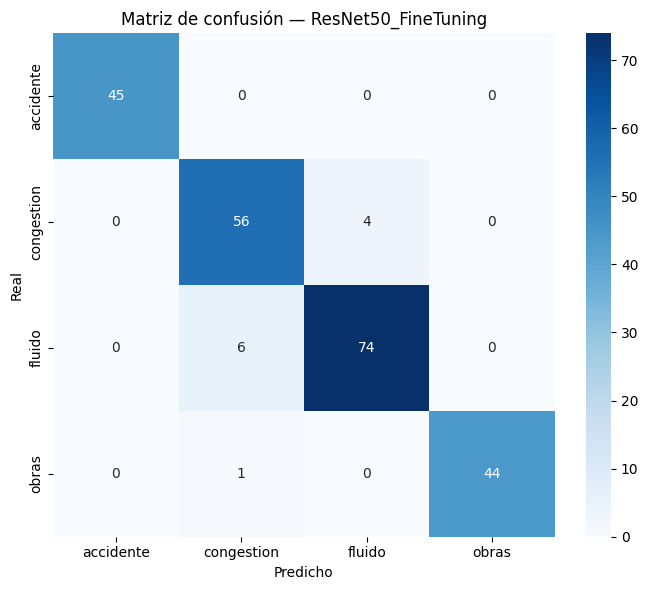


  EfficientNetB0_FineTuning — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.93      0.91      0.92        45
  congestion       0.85      0.93      0.89        60
      fluido       0.96      0.91      0.94        80
       obras       0.98      0.96      0.97        45

    accuracy                           0.93       230
   macro avg       0.93      0.93      0.93       230
weighted avg       0.93      0.93      0.93       230



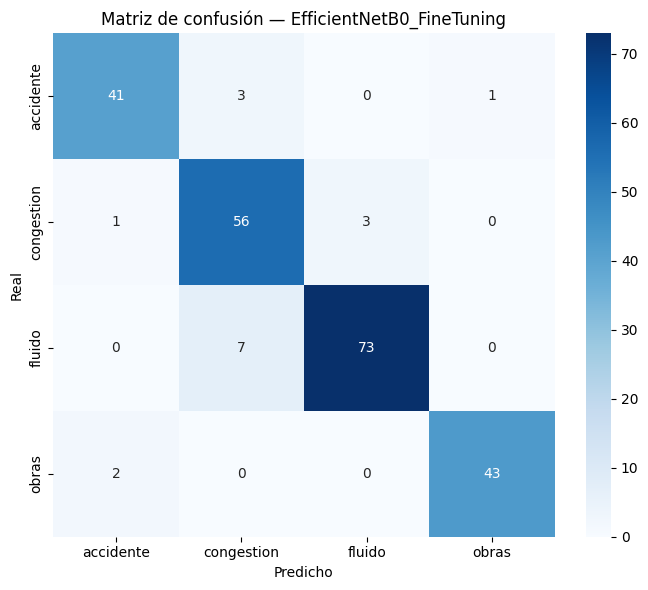

In [33]:
evaluar_modelo(baseline, 'BaselineCNN')
evaluar_modelo(resnet_ft, 'ResNet50_FineTuning')
evaluar_modelo(efficientnet_ft, 'EfficientNetB0_FineTuning')

**Tabla comparativa**

In [34]:
from sklearn.metrics import accuracy_score, f1_score

def get_metrics(model):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

print("=" * 55)
print(f"  {'Modelo':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 55)

modelos = [
    (baseline,        'Baseline CNN'),
    (resnet,          'ResNet50 (Transfer)'),
    (resnet_ft,       'ResNet50 (Fine-tuning)'),
    (efficientnet,    'EfficientNetB0 (Transfer)'),
    (efficientnet_ft, 'EfficientNetB0 (Fine-tuning)'),
]

for model, name in modelos:
    acc, f1 = get_metrics(model)
    print(f"  {name:<25} {acc:>10.4f} {f1:>10.4f}")

print("=" * 55)

  Modelo                      Accuracy   Macro F1
  Baseline CNN                  0.9304     0.9299
  ResNet50 (Transfer)           0.9217     0.9263
  ResNet50 (Fine-tuning)        0.9522     0.9590
  EfficientNetB0 (Transfer)     0.9217     0.9210
  EfficientNetB0 (Fine-tuning)     0.9261     0.9281


**Curvas comparativas**

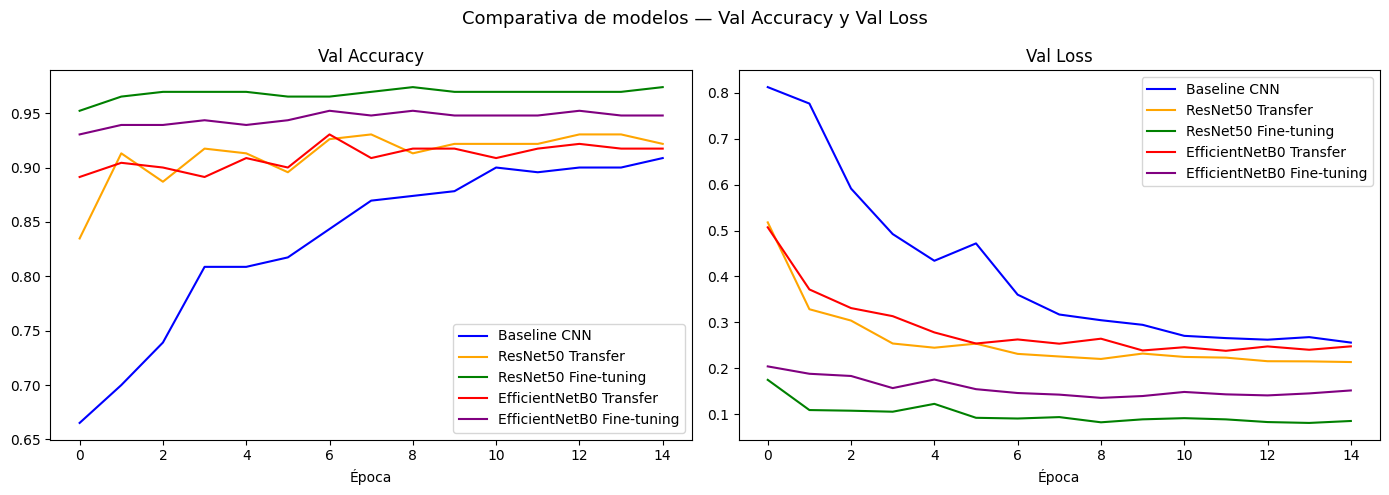

Comparativa guardada en Drive


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa de modelos — Val Accuracy y Val Loss', fontsize=13)

configs = [
    (history_base,    'Baseline CNN',                  'blue'),
    (history_res,     'ResNet50 Transfer',              'orange'),
    (history_ft,      'ResNet50 Fine-tuning',           'green'),
    (history_eff,     'EfficientNetB0 Transfer',        'red'),
    (history_eff_ft,  'EfficientNetB0 Fine-tuning',     'purple'),
]

for history, name, color in configs:
    axes[0].plot(history['val_acc'],  label=name, color=color)
    axes[1].plot(history['val_loss'], label=name, color=color)

axes[0].set_title('Val Accuracy')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].set_title('Val Loss')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/comparativa_modelos.png', dpi=150)
plt.show()
print("Comparativa guardada en Drive")

**Instalar e importar Grad-CAM**

In [36]:
!pip install grad-cam -q

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("✓ Grad-CAM instalado")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ Grad-CAM instalado


**Función de visualización Grad-CAM**

In [37]:
# Clases en el mismo orden que durante el entrenamiento
CLASS_NAMES = ['accidente', 'congestion', 'fluido', 'obras']

# Transform para preprocesar la imagen
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def gradcam_imagen(model, target_layer, img_path, titulo=''):
    # Cargar imagen
    img_pil = Image.open(img_path).convert('RGB').resize((224, 224))
    img_np  = np.array(img_pil) / 255.0  # para visualización
    img_tensor = preprocess(img_pil).unsqueeze(0).to(device)

    # Predicción
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs  = torch.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        pred_cls = CLASS_NAMES[pred_idx]
        confianza = probs[pred_idx].item()

    # Grad-CAM sobre la clase predicha
    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]
    visualization = show_cam_on_image(img_np.astype(np.float32),
                                      grayscale_cam, use_rgb=True)

    # Mostrar
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'{titulo}\nPredicción: {pred_cls} ({confianza:.2%})', fontsize=12)
    axes[0].imshow(img_pil)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')
    axes[1].imshow(visualization)
    axes[1].set_title('Grad-CAM — zona de activación')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/TFM/gradcam_{titulo.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Predicción: {pred_cls} ({confianza:.2%})")
    print(f"Probabilidades: { {CLASS_NAMES[i]: f'{probs[i]:.4f}' for i in range(4)} }")

print("✓ Función Grad-CAM definida")

✓ Función Grad-CAM definida


**Definir capa objetivo para cada modelo**

In [38]:
# Capa objetivo para ResNet50 (última capa de layer4)
target_layer_resnet = resnet_ft.layer4[-1]

print("✓ Capa objetivo definida: resnet_ft.layer4[-1]")
print(f"  Tipo: {type(target_layer_resnet)}")

✓ Capa objetivo definida: resnet_ft.layer4[-1]
  Tipo: <class 'torchvision.models.resnet.Bottleneck'>


**Subir imágenes de prueba y ejecutar Grad-CAM**

Sube las imágenes que quieras analizar con Grad-CAM


Saving ejemplo_accidente_correcto.png to ejemplo_accidente_correcto.png
Saving ejemplo_accidente_error.png to ejemplo_accidente_error.png
Saving ejemplo_congestion_error.png to ejemplo_congestion_error.png
Saving ejemplo_obras_correcto.png to ejemplo_obras_correcto.png


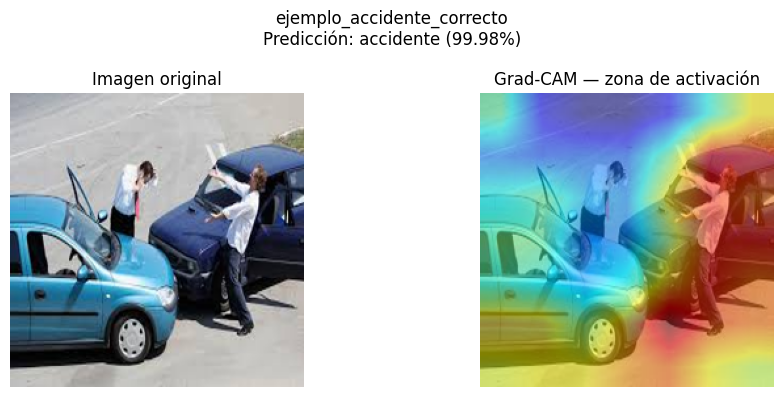

Predicción: accidente (99.98%)
Probabilidades: {'accidente': '0.9998', 'congestion': '0.0000', 'fluido': '0.0001', 'obras': '0.0001'}


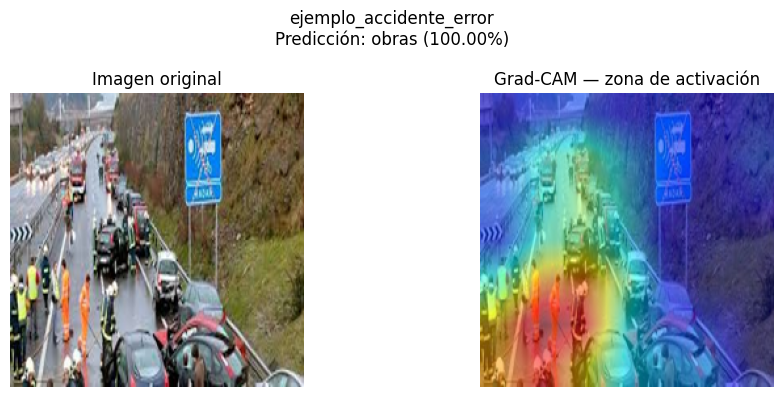

Predicción: obras (100.00%)
Probabilidades: {'accidente': '0.0000', 'congestion': '0.0000', 'fluido': '0.0000', 'obras': '1.0000'}


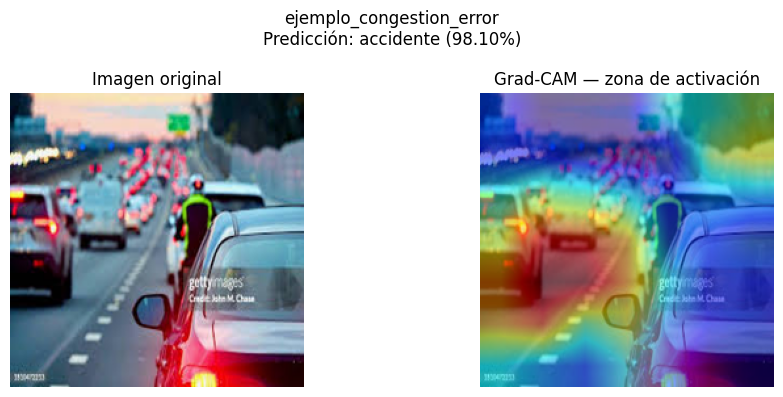

Predicción: accidente (98.10%)
Probabilidades: {'accidente': '0.9810', 'congestion': '0.0001', 'fluido': '0.0000', 'obras': '0.0188'}


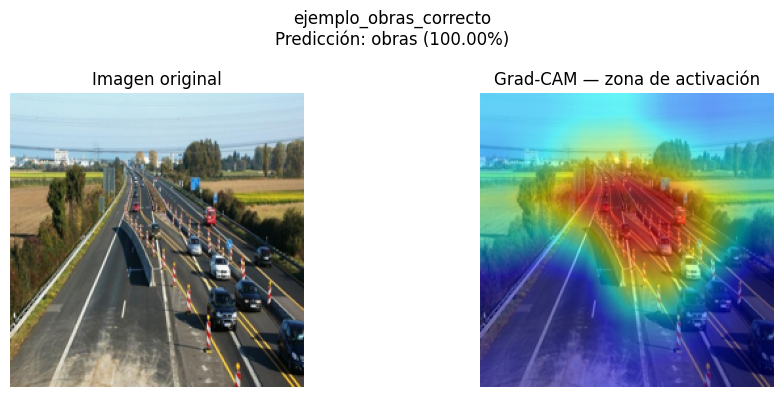

Predicción: obras (100.00%)
Probabilidades: {'accidente': '0.0000', 'congestion': '0.0000', 'fluido': '0.0000', 'obras': '1.0000'}


In [39]:
from google.colab import files

print("Sube las imágenes que quieras analizar con Grad-CAM")
uploaded = files.upload()

for filename in uploaded.keys():
    ruta = f'/content/{filename}'
    gradcam_imagen(
        model=resnet_ft,
        target_layer=target_layer_resnet,
        img_path=ruta,
        titulo=filename.replace('.jpg','').replace('.jpeg','').replace('.png','')
    )

**Validacion cruzada entre fuentes de datos**

In [40]:
import os, torch
import numpy as np
import pandas as pd
from collections import defaultdict
from PIL import Image
from torchvision import transforms

# Prefijos asignados en el pipeline de construcción del dataset:
#   cityscapes_XXXXX.jpg  → Cityscapes  (clase fluido)
#   singapore_XXXXX.jpg   → Singapore   (clases fluido y congestion)
#   roboflow_XXXXX.jpg    → Roboflow    (clases accidente y obras)
#   aug_XXXXX.jpg         → imagen sintética de augmentation

def detectar_fuente(filename):
    fn = filename.lower()
    if fn.startswith('cityscapes_'):
        return 'Cityscapes'
    elif fn.startswith('singapore_'):
        return 'Singapore'
    elif fn.startswith('roboflow_'):
        return 'Roboflow'
    elif fn.startswith('aug_'):
        return 'Augmentation'
    else:
        return 'otro'

# Recorrer el test set y anotar fuente por imagen
CLASS_NAMES_ORDERED = image_datasets['test'].classes  # orden del ImageFolder

test_samples = []
for cls_idx, cls_name in enumerate(CLASS_NAMES_ORDERED):
    cls_dir = os.path.join(SPLIT_DIR, 'test', cls_name)
    if not os.path.exists(cls_dir):
        continue
    for fname in sorted(os.listdir(cls_dir)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            test_samples.append({
                'path':     os.path.join(cls_dir, fname),
                'real_idx': cls_idx,
                'real':     cls_name,
                'fuente':   detectar_fuente(fname),
                'fname':    fname
            })

print(f"Imágenes en test: {len(test_samples)}")
print()

# Resumen distribución por clase × fuente
resumen = defaultdict(lambda: defaultdict(int))
for s in test_samples:
    resumen[s['real']][s['fuente']] += 1

print("Distribución por clase y fuente:")
for cls in CLASS_NAMES_ORDERED:
    print(f"  {cls}: {dict(resumen[cls])}")


Imágenes en test: 230

Distribución por clase y fuente:
  accidente: {'Augmentation': 31, 'Roboflow': 14}
  congestion: {'Augmentation': 7, 'Singapore': 53}
  fluido: {'Cityscapes': 9, 'Singapore': 71}
  obras: {'Augmentation': 22, 'Roboflow': 23}


**Inferencia con metadato de fuente**

In [41]:
preprocess_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predecir(model, img_path):
    model.eval()
    img    = Image.open(img_path).convert('RGB')
    tensor = preprocess_val(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    return pred_idx, float(probs[pred_idx])

resultados = []
for s in test_samples:
    pred_idx, conf = predecir(resnet_ft, s['path'])
    resultados.append({
        **s,
        'pred_idx':  pred_idx,
        'pred':      CLASS_NAMES_ORDERED[pred_idx],
        'confianza': conf,
        'correcto':  (pred_idx == s['real_idx'])
    })

df = pd.DataFrame(resultados)
print(f"Inferencia completada. Accuracy global: {df['correcto'].mean():.3f}")


Inferencia completada. Accuracy global: 0.952


**Accuracy por clase y fuente**

In [42]:
print("=" * 60)
print("  ACCURACY POR CLASE Y FUENTE DE ORIGEN")
print("=" * 60)

for cls in CLASS_NAMES_ORDERED:
    sub_cls = df[df['real'] == cls]
    acc_global = sub_cls['correcto'].mean()
    fuentes = [f for f in sub_cls['fuente'].unique() if f != 'Augmentation']
    print(f"\n{cls}  (acc global = {acc_global:.3f})")
    accs_fuente = []
    for src in fuentes:
        sub = sub_cls[sub_cls['fuente'] == src]
        acc = sub['correcto'].mean()
        accs_fuente.append(acc)
        print(f"  {src:<18} acc={acc:.3f}  n={len(sub)}")
    if len(accs_fuente) >= 2:
        rango = max(accs_fuente) - min(accs_fuente)
        flag  = '⚠ posible sesgo de dataset' if rango > 0.15 else '✓ estable'
        print(f"  → rango entre fuentes = {rango:.3f}  {flag}")


  ACCURACY POR CLASE Y FUENTE DE ORIGEN

accidente  (acc global = 1.000)
  Roboflow           acc=1.000  n=14

congestion  (acc global = 0.933)
  Singapore          acc=0.925  n=53

fluido  (acc global = 0.925)
  Cityscapes         acc=1.000  n=9
  Singapore          acc=0.915  n=71
  → rango entre fuentes = 0.085  ✓ estable

obras  (acc global = 0.978)
  Roboflow           acc=0.957  n=23


**Matrices de confución por fuente**

A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.


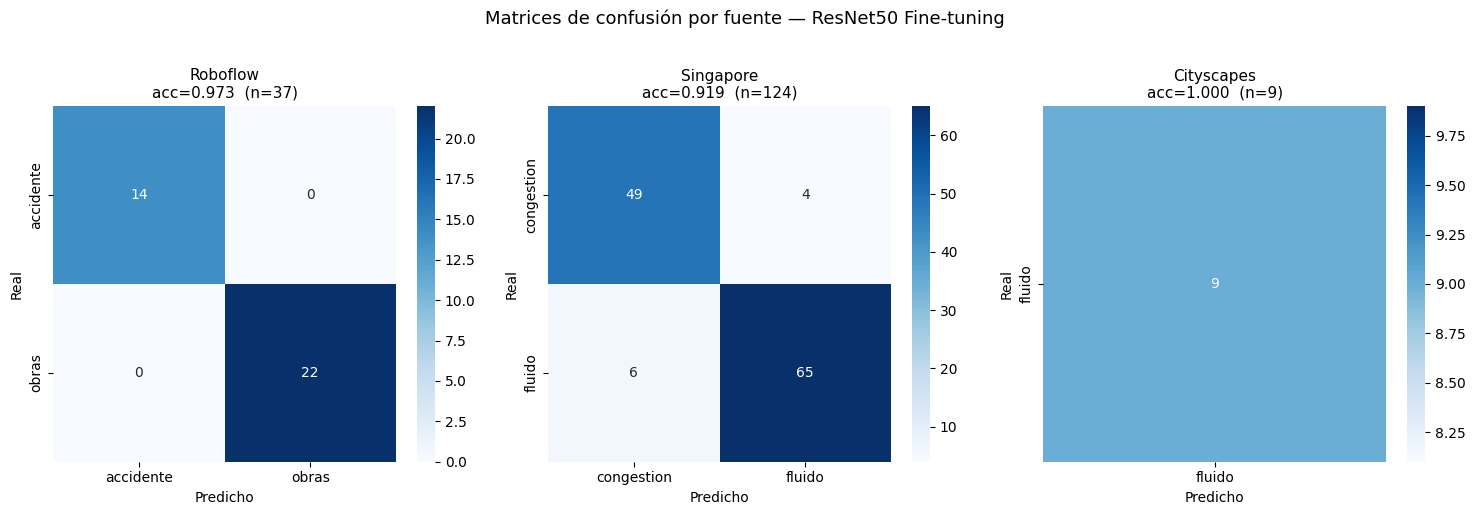

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

fuentes_plot = [f for f in df['fuente'].unique() if f != 'Augmentation']
n = len(fuentes_plot)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, src in zip(axes, fuentes_plot):
    sub = df[df['fuente'] == src]
    clases_idx = sorted(sub['real_idx'].unique())
    nombres    = [CLASS_NAMES_ORDERED[i] for i in clases_idx]
    cm = confusion_matrix(sub['real_idx'], sub['pred_idx'], labels=clases_idx)
    acc = sub['correcto'].mean()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nombres, yticklabels=nombres, ax=ax)
    ax.set_title(f"{src}\nacc={acc:.3f}  (n={len(sub)})", fontsize=11)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión por fuente — ResNet50 Fine-tuning',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Errores sistemáticos por fuente**

In [44]:
print("=" * 60)
print("  ERRORES SISTEMÁTICOS POR CLASE Y FUENTE")
print("=" * 60)

errores = df[df['correcto'] == False]
print(f"Total errores: {len(errores)} de {len(df)} ({len(errores)/len(df)*100:.1f}%)\n")

for cls in CLASS_NAMES_ORDERED:
    sub_err = errores[errores['real'] == cls]
    if len(sub_err) == 0:
        print(f"{cls}: sin errores ✓")
        continue
    print(f"{cls}:")
    for src in sub_err['fuente'].unique():
        sub_src_err = sub_err[sub_err['fuente'] == src]
        total_src   = len(df[(df['real'] == cls) & (df['fuente'] == src)])
        pct = len(sub_src_err) / total_src * 100 if total_src > 0 else 0
        # Confusión más frecuente en esta fuente
        top_pred = sub_src_err['pred'].value_counts().index[0]
        top_n    = sub_src_err['pred'].value_counts().iloc[0]
        flag = '⚠ shortcut probable' if pct > 60 else ''
        print(f"  [{src}]  {len(sub_src_err)}/{total_src} errores ({pct:.0f}%)  "
              f"→ clasificado principalmente como '{top_pred}' ({top_n}x)  {flag}")
    print()


  ERRORES SISTEMÁTICOS POR CLASE Y FUENTE
Total errores: 11 de 230 (4.8%)

accidente: sin errores ✓
congestion:
  [Singapore]  4/53 errores (8%)  → clasificado principalmente como 'fluido' (4x)  

fluido:
  [Singapore]  6/71 errores (8%)  → clasificado principalmente como 'congestion' (6x)  

obras:
  [Roboflow]  1/23 errores (4%)  → clasificado principalmente como 'congestion' (1x)  



**Test de Fisher. ¿Es la accuracy independiente de la fuente?**

In [45]:
from scipy.stats import fisher_exact
from itertools import combinations

print("=" * 60)
print("  TEST DE FISHER POR PAR DE FUENTES")
print("=" * 60)
print("H₀: accuracy igual entre fuentes  |  p < 0.05 → sesgo detectado\n")

for cls in CLASS_NAMES_ORDERED:
    sub_cls = df[df['real'] == cls]
    fuentes = [f for f in sub_cls['fuente'].unique() if f != 'Augmentation']
    if len(fuentes) < 2:
        print(f"{cls}: solo 1 fuente → test no aplicable")
        continue
    print(f"{cls}:")
    for src_a, src_b in combinations(fuentes, 2):
        sub_a = sub_cls[sub_cls['fuente'] == src_a]
        sub_b = sub_cls[sub_cls['fuente'] == src_b]
        ok_a, err_a = sub_a['correcto'].sum(), (~sub_a['correcto']).sum()
        ok_b, err_b = sub_b['correcto'].sum(), (~sub_b['correcto']).sum()
        _, pval = fisher_exact([[ok_a, err_a], [ok_b, err_b]], alternative='two-sided')
        flag = '⚠ SIGNIFICATIVO' if pval < 0.05 else '✓ no significativo'
        print(f"  {src_a} (acc={ok_a/len(sub_a):.3f}, n={len(sub_a)}) vs "
              f"{src_b} (acc={ok_b/len(sub_b):.3f}, n={len(sub_b)})")
        print(f"    p = {pval:.4f}  →  {flag}")
    print()
print("Nota: con n < 20 por grupo el test puede carecer de potencia estadística.")


  TEST DE FISHER POR PAR DE FUENTES
H₀: accuracy igual entre fuentes  |  p < 0.05 → sesgo detectado

accidente: solo 1 fuente → test no aplicable
congestion: solo 1 fuente → test no aplicable
fluido:
  Cityscapes (acc=1.000, n=9) vs Singapore (acc=0.915, n=71)
    p = 1.0000  →  ✓ no significativo

obras: solo 1 fuente → test no aplicable
Nota: con n < 20 por grupo el test puede carecer de potencia estadística.


**Veredicto final: ¿evento o dataset?**

In [46]:
print("=" * 60)
print("  VEREDICTO FINAL POR CLASE")
print("=" * 60)
print()

for cls in CLASS_NAMES_ORDERED:
    sub_cls = df[df['real'] == cls]
    fuentes = [f for f in sub_cls['fuente'].unique() if f != 'Augmentation']

    if len(fuentes) < 2:
        veredicto = "indeterminado (1 fuente)"
    else:
        accs  = [sub_cls[sub_cls['fuente'] == f]['correcto'].mean() for f in fuentes]
        rango = max(accs) - min(accs)

        sub_err = errores[errores['real'] == cls]
        if len(sub_err) > 0:
            top_pred_pct = sub_err['pred'].value_counts().iloc[0] / len(sub_err)
        else:
            top_pred_pct = 0

        if rango > 0.20:
            veredicto = "⚠  SESGO DE DATASET  (rango accuracy entre fuentes > 0.20)"
        elif top_pred_pct > 0.70:
            veredicto = "⚠  SESGO SEMÁNTICO   (errores concentrados en una predicción)"
        else:
            veredicto = "✓  EVENTO            (accuracy estable entre fuentes)"

    print(f"  {cls:<12}  {veredicto}")

print()
print("-" * 60)
print("Interpretación:")
print("  ✓ EVENTO     → el modelo ha aprendido la semántica de la clase")
print("  ⚠ DATASET    → la accuracy depende del origen visual de la imagen")
print("  ⚠ SEMÁNTICO  → el modelo usa un atajo visual (color, perspectiva…)")
print()
print("Los sesgos detectados aquí son los que se deben corregir ampliando")
print("cada clase afectada con imágenes de fuentes adicionales.")


  VEREDICTO FINAL POR CLASE

  accidente     indeterminado (1 fuente)
  congestion    indeterminado (1 fuente)
  fluido        ⚠  SESGO SEMÁNTICO   (errores concentrados en una predicción)
  obras         indeterminado (1 fuente)

------------------------------------------------------------
Interpretación:
  ✓ EVENTO     → el modelo ha aprendido la semántica de la clase
  ⚠ DATASET    → la accuracy depende del origen visual de la imagen
  ⚠ SEMÁNTICO  → el modelo usa un atajo visual (color, perspectiva…)

Los sesgos detectados aquí son los que se deben corregir ampliando
cada clase afectada con imágenes de fuentes adicionales.
